In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('../data/cardio_cleaned.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (68517, 12)

First 5 rows:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [2]:
# ── Derived Features ──────────────────────────────────────────

# 1. Pulse Pressure (difference between systolic and diastolic)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# 2. BMI (Body Mass Index)
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

# 3. Cholesterol Ratio (using proxy since we only have categorical cholesterol)
df['chol_glucose_risk'] = df['cholesterol'] + df['gluc']

# 4. Age Groups
df['age_group'] = pd.cut(df['age'], 
                          bins=[0, 40, 50, 60, 100], 
                          labels=[0, 1, 2, 3])
df['age_group'] = df['age_group'].astype(int)

# 5. BMI Categories
df['bmi_category'] = pd.cut(df['bmi'],
                              bins=[0, 18.5, 25, 30, 100],
                              labels=[0, 1, 2, 3])
df['bmi_category'] = df['bmi_category'].astype(int)

# 6. Hypertension flag
df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)

print("New features added!")
print("New shape:", df.shape)
print("\nNew columns:", ['pulse_pressure', 'bmi', 'chol_glucose_risk', 
                         'age_group', 'bmi_category', 'hypertension'])
df.head()

New features added!
New shape: (68517, 18)

New columns: ['pulse_pressure', 'bmi', 'chol_glucose_risk', 'age_group', 'bmi_category', 'hypertension']


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,pulse_pressure,bmi,chol_glucose_risk,age_group,bmi_category,hypertension
0,50,2,168,62.0,110,80,1,1,0,0,1,0,30,21.967120,2,1,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1,50,34.927679,4,2,3,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1,60,23.507805,4,2,1,0
3,48,2,169,82.0,150,100,1,1,0,0,1,1,50,28.710479,2,1,2,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0,40,23.011177,2,1,1,0


In [3]:
# Save the feature engineered dataset
df.to_csv('../data/cardio_features.csv', index=False)
print("Feature engineered dataset saved!")

# Separate features (X) and target (y)
X = df.drop(columns=['cardio'])
y = df['cardio']

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nDisease rate:", round(y.mean() * 100, 2), "%")

Feature engineered dataset saved!

Features shape: (68517, 17)
Target shape: (68517,)

Target distribution:
cardio
0    34637
1    33880
Name: count, dtype: int64

Disease rate: 49.45 %


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nData scaling complete!")

# Save scaler for later use in Flask
import joblib
joblib.dump(scaler, '../backend/models/scaler.pkl')
print("Scaler saved!")

Training set: (47961, 17)
Validation set: (10278, 17)
Test set: (10278, 17)

Data scaling complete!
Scaler saved!


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Train Logistic Regression (baseline model)
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Evaluate on validation set
lr_val_pred = lr_model.predict(X_val_scaled)
lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]

lr_accuracy = accuracy_score(y_val, lr_val_pred)
lr_auc = roc_auc_score(y_val, lr_val_proba)

print("\n── Logistic Regression Results ──")
print(f"Accuracy:  {lr_accuracy:.4f} ({round(lr_accuracy*100, 2)}%)")
print(f"ROC-AUC:   {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, lr_val_pred, 
      target_names=['No Disease', 'Has Disease']))

Training Logistic Regression...

── Logistic Regression Results ──
Accuracy:  0.7319 (73.19%)
ROC-AUC:   0.7976

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.70      0.80      0.75      5170
 Has Disease       0.77      0.66      0.71      5108

    accuracy                           0.73     10278
   macro avg       0.74      0.73      0.73     10278
weighted avg       0.74      0.73      0.73     10278



In [6]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# Evaluate on validation set
rf_val_pred = rf_model.predict(X_val_scaled)
rf_val_proba = rf_model.predict_proba(X_val_scaled)[:, 1]

rf_accuracy = accuracy_score(y_val, rf_val_pred)
rf_auc = roc_auc_score(y_val, rf_val_proba)

print("\n── Random Forest Results ──")
print(f"Accuracy:  {rf_accuracy:.4f} ({round(rf_accuracy*100, 2)}%)")
print(f"ROC-AUC:   {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, rf_val_pred,
      target_names=['No Disease', 'Has Disease']))

Training Random Forest...

── Random Forest Results ──
Accuracy:  0.7368 (73.68%)
ROC-AUC:   0.8046

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.72      0.79      0.75      5170
 Has Disease       0.76      0.68      0.72      5108

    accuracy                           0.74     10278
   macro avg       0.74      0.74      0.74     10278
weighted avg       0.74      0.74      0.74     10278



In [7]:
from xgboost import XGBClassifier

# Train XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)

# Evaluate on validation set
xgb_val_pred = xgb_model.predict(X_val_scaled)
xgb_val_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]

xgb_accuracy = accuracy_score(y_val, xgb_val_pred)
xgb_auc = roc_auc_score(y_val, xgb_val_proba)

print("\n── XGBoost Results ──")
print(f"Accuracy:  {xgb_accuracy:.4f} ({round(xgb_accuracy*100, 2)}%)")
print(f"ROC-AUC:   {xgb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, xgb_val_pred,
      target_names=['No Disease', 'Has Disease']))

Training XGBoost...

── XGBoost Results ──
Accuracy:  0.7366 (73.66%)
ROC-AUC:   0.8061

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.72      0.78      0.75      5170
 Has Disease       0.76      0.69      0.72      5108

    accuracy                           0.74     10278
   macro avg       0.74      0.74      0.74     10278
weighted avg       0.74      0.74      0.74     10278



── Model Comparison (Validation Set) ──

                 Model  Accuracy %  ROC-AUC
0  Logistic Regression       73.19   0.7976
1        Random Forest       73.68   0.8046
2              XGBoost       73.66   0.8061


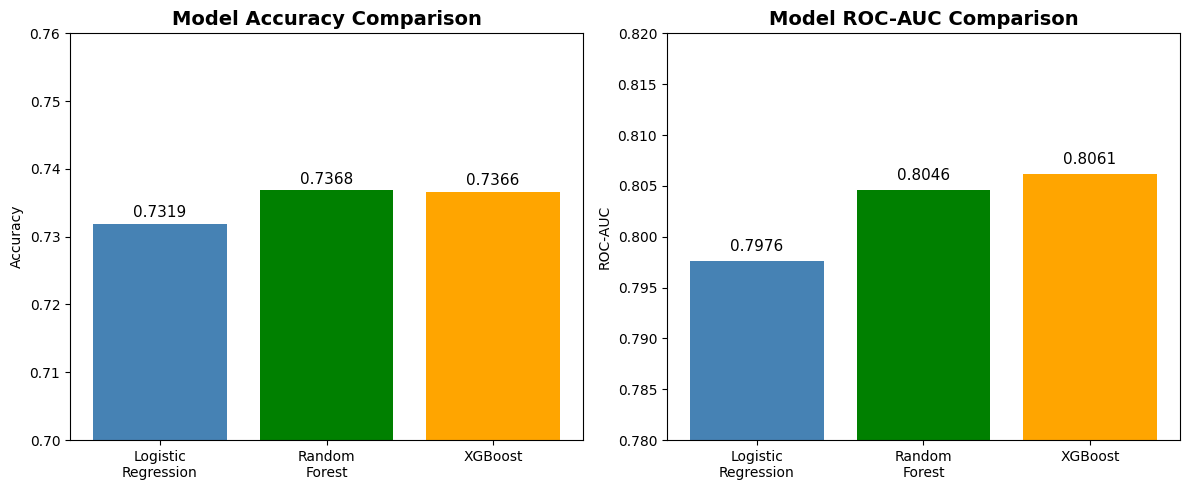


Comparison chart saved!


In [8]:
# Compare all three models
print("── Model Comparison (Validation Set) ──\n")

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_accuracy, rf_accuracy, xgb_accuracy],
    'ROC-AUC': [lr_auc, rf_auc, xgb_auc]
}

results_df = pd.DataFrame(results)
results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(2)
results_df['ROC-AUC'] = results_df['ROC-AUC'].round(4)
print(results_df[['Model', 'Accuracy %', 'ROC-AUC']])

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
accuracies = [lr_accuracy, rf_accuracy, xgb_accuracy]
aucs = [lr_auc, rf_auc, xgb_auc]

# Accuracy chart
bars1 = ax1.bar(models, accuracies, color=['steelblue', 'green', 'orange'])
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.70, 0.76)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', fontsize=11)

# AUC chart
bars2 = ax2.bar(models, aucs, color=['steelblue', 'green', 'orange'])
ax2.set_title('Model ROC-AUC Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('ROC-AUC')
ax2.set_ylim(0.78, 0.82)
for bar, auc in zip(bars2, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{auc:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/model_comparison.png')
plt.show()
print("\nComparison chart saved!")

── Final Evaluation on Test Set (XGBoost) ──

Test Accuracy:  0.7356 (73.56%)
Test ROC-AUC:   0.7977

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.72      0.78      0.75      5262
 Has Disease       0.75      0.69      0.72      5016

    accuracy                           0.74     10278
   macro avg       0.74      0.73      0.73     10278
weighted avg       0.74      0.74      0.73     10278



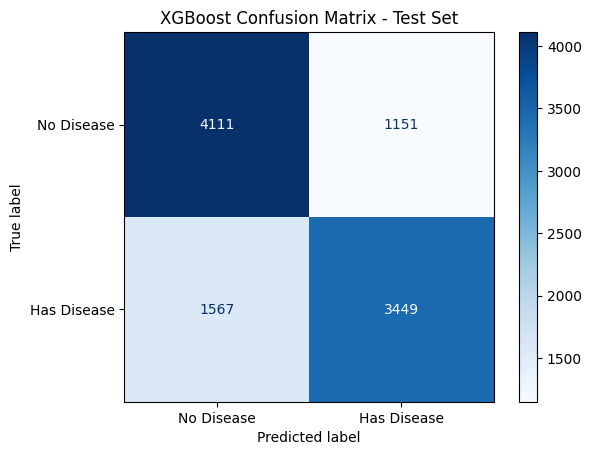


Confusion matrix saved!


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Final evaluation on test set
print("── Final Evaluation on Test Set (XGBoost) ──\n")

xgb_test_pred = xgb_model.predict(X_test_scaled)
xgb_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test, xgb_test_pred)
test_auc = roc_auc_score(y_test, xgb_test_proba)

print(f"Test Accuracy:  {test_accuracy:.4f} ({round(test_accuracy*100, 2)}%)")
print(f"Test ROC-AUC:   {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_test_pred,
      target_names=['No Disease', 'Has Disease']))

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Has Disease'])
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix - Test Set')
plt.savefig('../data/confusion_matrix.png')
plt.show()
print("\nConfusion matrix saved!")

Generating SHAP explanations...


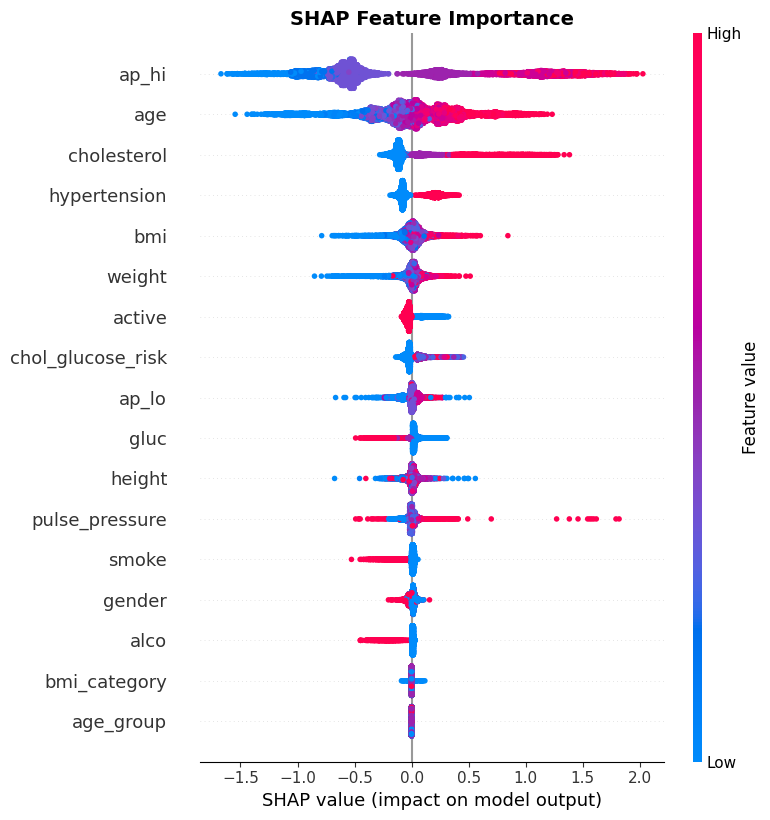

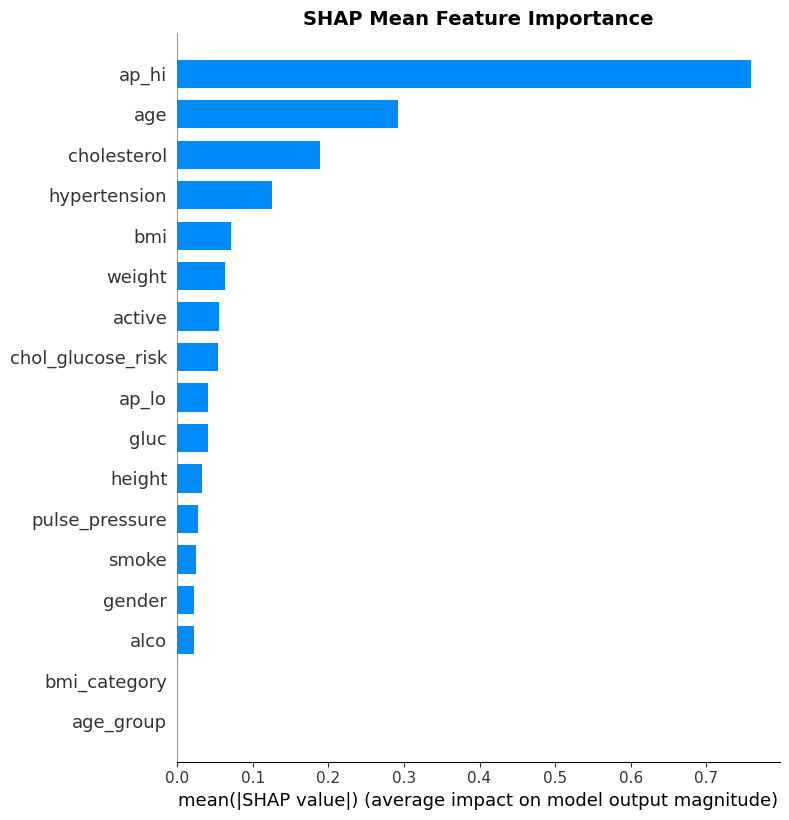

SHAP plots saved!


In [10]:
import shap

print("Generating SHAP explanations...")

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Plot 1: Feature Importance Summary
plt.figure()
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_summary.png', bbox_inches='tight')
plt.show()

# Plot 2: Bar chart of mean importance
plt.figure()
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('SHAP Mean Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_bar.png', bbox_inches='tight')
plt.show()

print("SHAP plots saved!")

In [11]:
import joblib

# Save XGBoost model
joblib.dump(xgb_model, '../backend/models/xgb_model.pkl')

# Save feature column names (needed for Flask later)
import json
feature_names = X.columns.tolist()
with open('../backend/models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("✅ XGBoost model saved!")
print("✅ Scaler already saved!")
print("✅ Feature names saved!")
print("\nSaved files:")
print("  backend/models/xgb_model.pkl")
print("  backend/models/scaler.pkl")
print("  backend/models/feature_names.json")
print("\nFeatures used by model:")
print(feature_names)

✅ XGBoost model saved!
✅ Scaler already saved!
✅ Feature names saved!

Saved files:
  backend/models/xgb_model.pkl
  backend/models/scaler.pkl
  backend/models/feature_names.json

Features used by model:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'pulse_pressure', 'bmi', 'chol_glucose_risk', 'age_group', 'bmi_category', 'hypertension']
